###Impersonadas


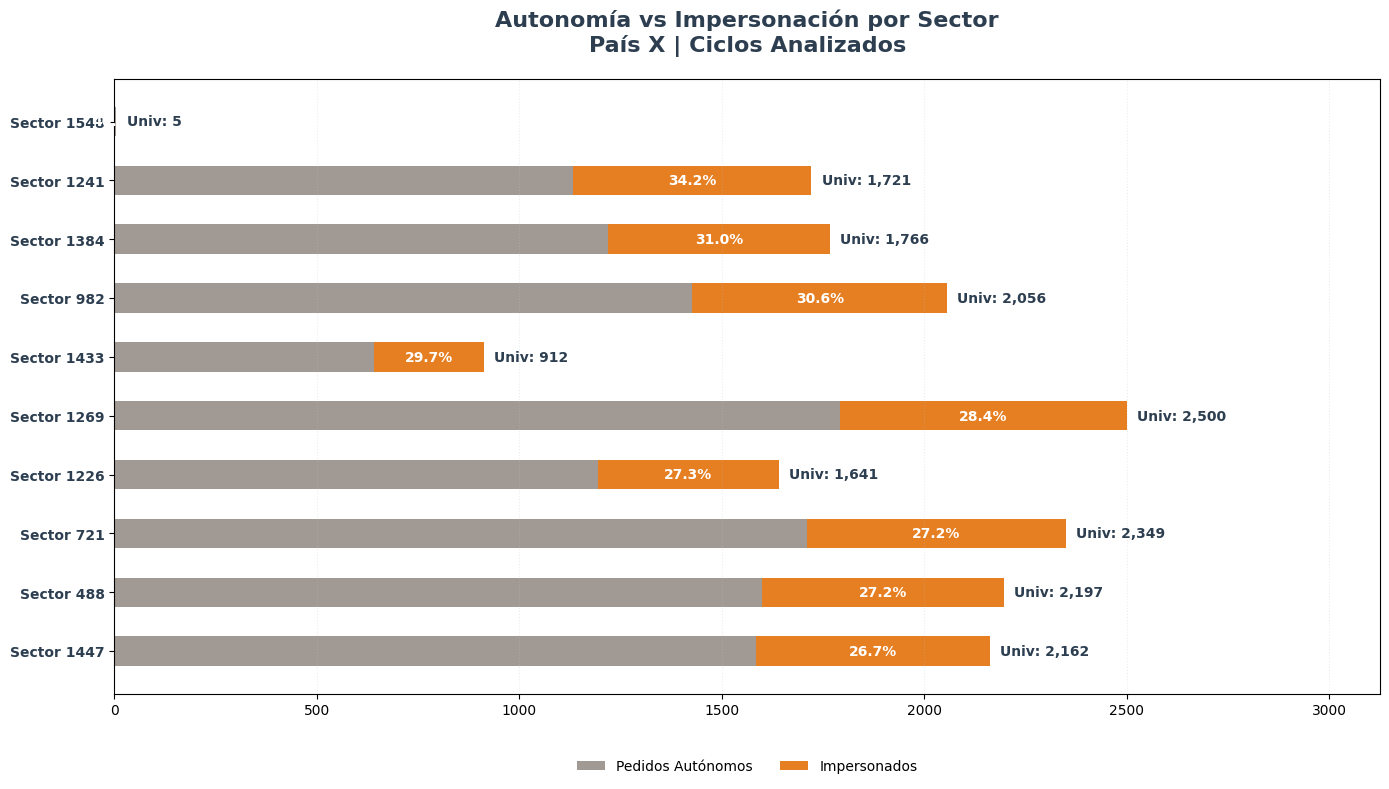

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# 1. Paleta 
COLOR_PRIMARY = '#E67E22'
COLOR_SECONDARY = '#A19A94'
COLOR_TEXT = '#2C3E50'
COLOR_GRID = '#BDC3C7'


df = pd.read_csv('impersonadas2.csv')
ciclos = [202601, 202602, 202603, 202604]

df_filt = df[
    (df['country_name'] == 'ARGENTINA') &
    (df['operational_cycle'].isin(ciclos))
].copy()


def clean_names(name):
    name = str(name).upper()
    
    if "ALEL" in name: return "Sector 1433"
    if "ANDUBAY" in name: return "Sector 972"
    if "GENESIS" in name: return "Sector 1468"
    if "CONEXI" in name: return "Sector 1229"
    
  
    match = re.search(r'\d+', name)
    if match:
        return f"Sector {match.group()}"
    
    return "Sector Otros"

df_filt['sector_name'] = df_filt['sector_name'].apply(clean_names)


sector_data = df_filt.groupby('sector_name').agg({
    'total_orders': 'sum',
    'total_impersonated': 'sum'
}).reset_index()

sector_data = sector_data[sector_data['total_orders'] > 0]

sector_data['total_auto'] = sector_data['total_orders'] - sector_data['total_impersonated']
sector_data['pct_imp'] = (sector_data['total_impersonated'] / sector_data['total_orders']) * 100


top_10 = sector_data.sort_values(by='pct_imp', ascending=False).head(10)

# 6. Gráfico
plt.figure(figsize=(14, 8))
y_pos = np.arange(len(top_10))
bar_height = 0.5

plt.barh(y_pos, top_10['total_auto'], height=bar_height, color=COLOR_SECONDARY, label='Pedidos Autónomos')
plt.barh(y_pos, top_10['total_impersonated'], left=top_10['total_auto'], height=bar_height, color=COLOR_PRIMARY, label='Impersonados')

plt.yticks(y_pos, top_10['sector_name'], fontweight='bold', color=COLOR_TEXT)

plt.title(
    'Autonomía vs Impersonación por Sector\nPaís X | Ciclos Analizados',
    fontsize=16,
    fontweight='bold',
    color=COLOR_TEXT,
    pad=20
)

plt.gca().invert_yaxis()

plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

# 7. Labels
max_val = top_10['total_orders'].max()

for i, row in enumerate(top_10.itertuples()):
    
    # % impersonación dentro de la barra
    if row.pct_imp > 2:
        plt.text(
            row.total_auto + (row.total_impersonated / 2),
            i,
            f'{row.pct_imp:.1f}%',
            va='center',
            ha='center',
            color='white',
            fontweight='bold',
            fontsize=10
        )
    

    plt.text(
        row.total_orders + (max_val * 0.01),
        i,
        f'Univ: {int(row.total_orders):,}',
        va='center',
        color=COLOR_TEXT,
        fontweight='bold',
        fontsize=10
    )


plt.xlim(0, max_val * 1.25)
plt.grid(axis='x', linestyle=':', alpha=0.3, color=COLOR_GRID)

plt.tight_layout()

plt.savefig('grafico_sectores_anonimo.png')


plt.show()